In [1]:
import os
import time
import h5py
import numpy
import argparse
from matplotlib import pyplot
from matplotlib import colors

In [2]:
# Tag
tag='Y10'
folder="/global/cfs/cdirs/lsst/groups/MCP/CosmoCloud/ZCloud/"

In [3]:
# Path
plot_folder = os.path.join(folder, 'PLOT/')
model_folder = os.path.join(folder, 'MODEL/')
dataset_folder = os.path.join(folder, 'DATASET/')
ensemble_folder = os.path.join(folder, 'ENSEMBLE/')
notebook_folder = os.path.join(folder, 'NOTEBOOK/')
summarize_folder = os.path.join(folder, 'SUMMARIZE/')

In [4]:
# Configuration
os.environ['PATH'] = '/global/homes/y/yhzhang/opt/texlive/bin/x86_64-linux:' + os.environ['PATH']
pyplot.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
pyplot.rcParams['pgf.texsystem'] = 'pdflatex'
pyplot.rcParams['text.usetex'] = True
pyplot.rcParams['font.size'] = 20

In [5]:
# Redshift
z1 = 0.0
z2 = 3.0
grid_size = 300
data_size = grid_size + 1
z_grid = numpy.linspace(z1, z2, grid_size + 1)

# Bin
with h5py.File(os.path.join(model_folder, '{}/SELECT/DATA0.hdf5'.format(tag)), 'r') as file:
    bin_lens_size = len(file['bin_lens'][...]) - 1
    bin_source_size = len(file['bin_source'][...]) - 1

# Summarize Lens
with h5py.File(os.path.join(ensemble_folder, '{}/LENS/SOM.hdf5'.format(tag)), 'r') as file:
    som_lens = file['data'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/LENS/MODEL.hdf5'.format(tag)), 'r') as file:
    model_lens = file['data'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/LENS/PRODUCT.hdf5'.format(tag)), 'r') as file:
    product_lens = file['data'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/LENS/HISTOGRAM.hdf5'.format(tag)), 'r') as file:
    histogram_lens = file['data'][...]

# Summarize Source
with h5py.File(os.path.join(ensemble_folder, '{}/SOURCE/SOM.hdf5'.format(tag)), 'r') as file:
    som_source = file['data'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/SOURCE/MODEL.hdf5'.format(tag)), 'r') as file:
    model_source = file['data'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/SOURCE/PRODUCT.hdf5'.format(tag)), 'r') as file:
    product_source = file['data'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/SOURCE/HISTOGRAM.hdf5'.format(tag)), 'r') as file:
    histogram_source = file['data'][...]

# Matrix Lens
som_matrix_lens = numpy.cov(numpy.reshape(som_lens, (-1, bin_lens_size * data_size)), rowvar=False)

model_matrix_lens = numpy.cov(numpy.reshape(model_lens, (-1, bin_lens_size * data_size)), rowvar=False)

product_matrix_lens = numpy.cov(numpy.reshape(product_lens, (-1, bin_lens_size * data_size)), rowvar=False)

histogram_matrix_lens = numpy.cov(numpy.reshape(histogram_lens, (-1, bin_lens_size * data_size)), rowvar=False)

# Matrix Source
som_matrix_source = numpy.cov(numpy.reshape(som_source, (-1, bin_source_size * data_size)), rowvar=False)

model_matrix_source = numpy.cov(numpy.reshape(model_source, (-1, bin_source_size * data_size)), rowvar=False)

product_matrix_source = numpy.cov(numpy.reshape(product_source, (-1, bin_source_size * data_size)), rowvar=False)

histogram_matrix_source = numpy.cov(numpy.reshape(histogram_source, (-1, bin_source_size * data_size)), rowvar=False)

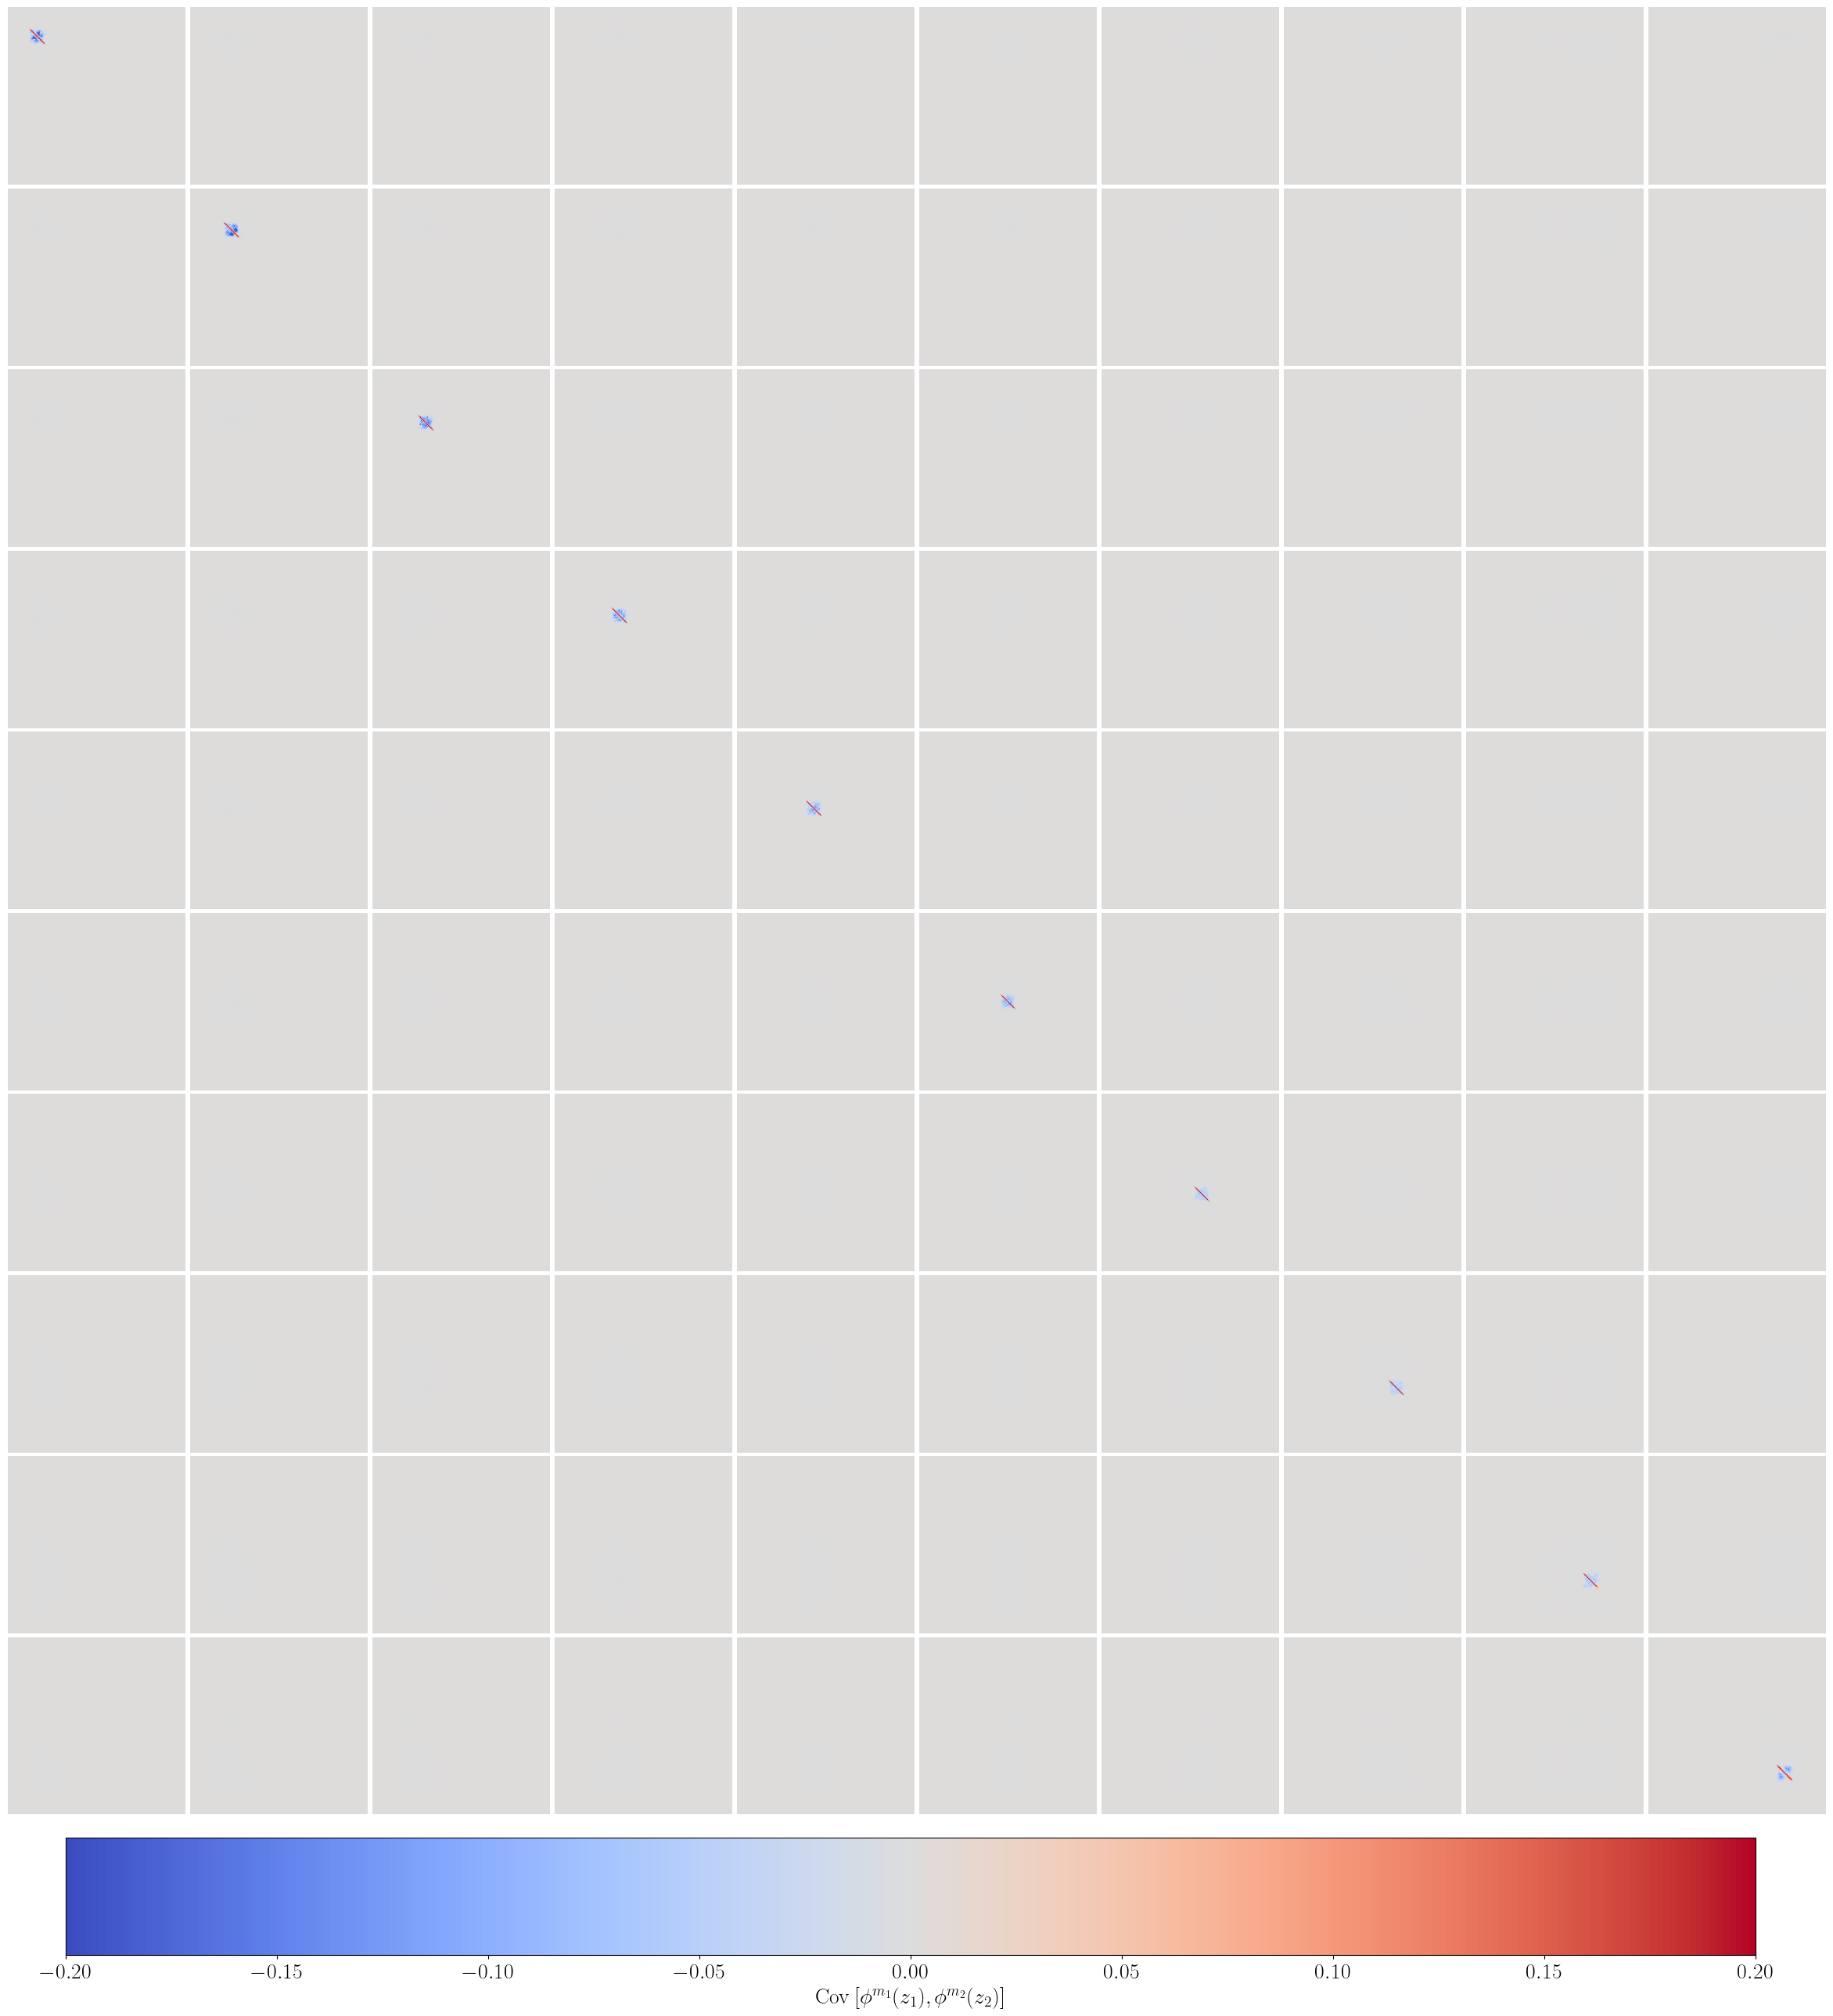

In [6]:
# SOM Lens
norm = colors.Normalize(vmin = -0.1, vmax = +0.1)
figure, plot = pyplot.subplots(nrows = bin_lens_size, ncols = bin_lens_size, figsize = (3 * bin_lens_size, 3 * bin_lens_size))

for m in range(bin_lens_size):
    for n in range(bin_lens_size):
        
        som_map = som_matrix_lens[n * data_size: n * data_size + data_size // 2, m * data_size: m * data_size + data_size // 2]
        image = plot[n, m].imshow(som_map, norm = norm, cmap = 'coolwarm', origin = 'upper')
        plot[n, m].axis('off')

cax = figure.add_axes([0.15, 0.05, 0.72, 0.05])
figure.subplots_adjust(wspace = 0.02, hspace = 0.02)

os.makedirs(plot_folder, exist_ok=True)
os.makedirs(os.path.join(plot_folder, '{}/COVARIANCE/'.format(tag)), exist_ok=True)

figure.colorbar(cax = cax, mappable = image, orientation = 'horizontal', label = r'$\mathrm{Cov} \: [\phi^{m_1} (z_1), \phi^{m_2} (z_2)]$')
figure.savefig(os.path.join(plot_folder, '{}/COVARIANCE/FIGURE_SOM_LENS.png'.format(tag)), bbox_inches='tight', format='png', dpi=512)

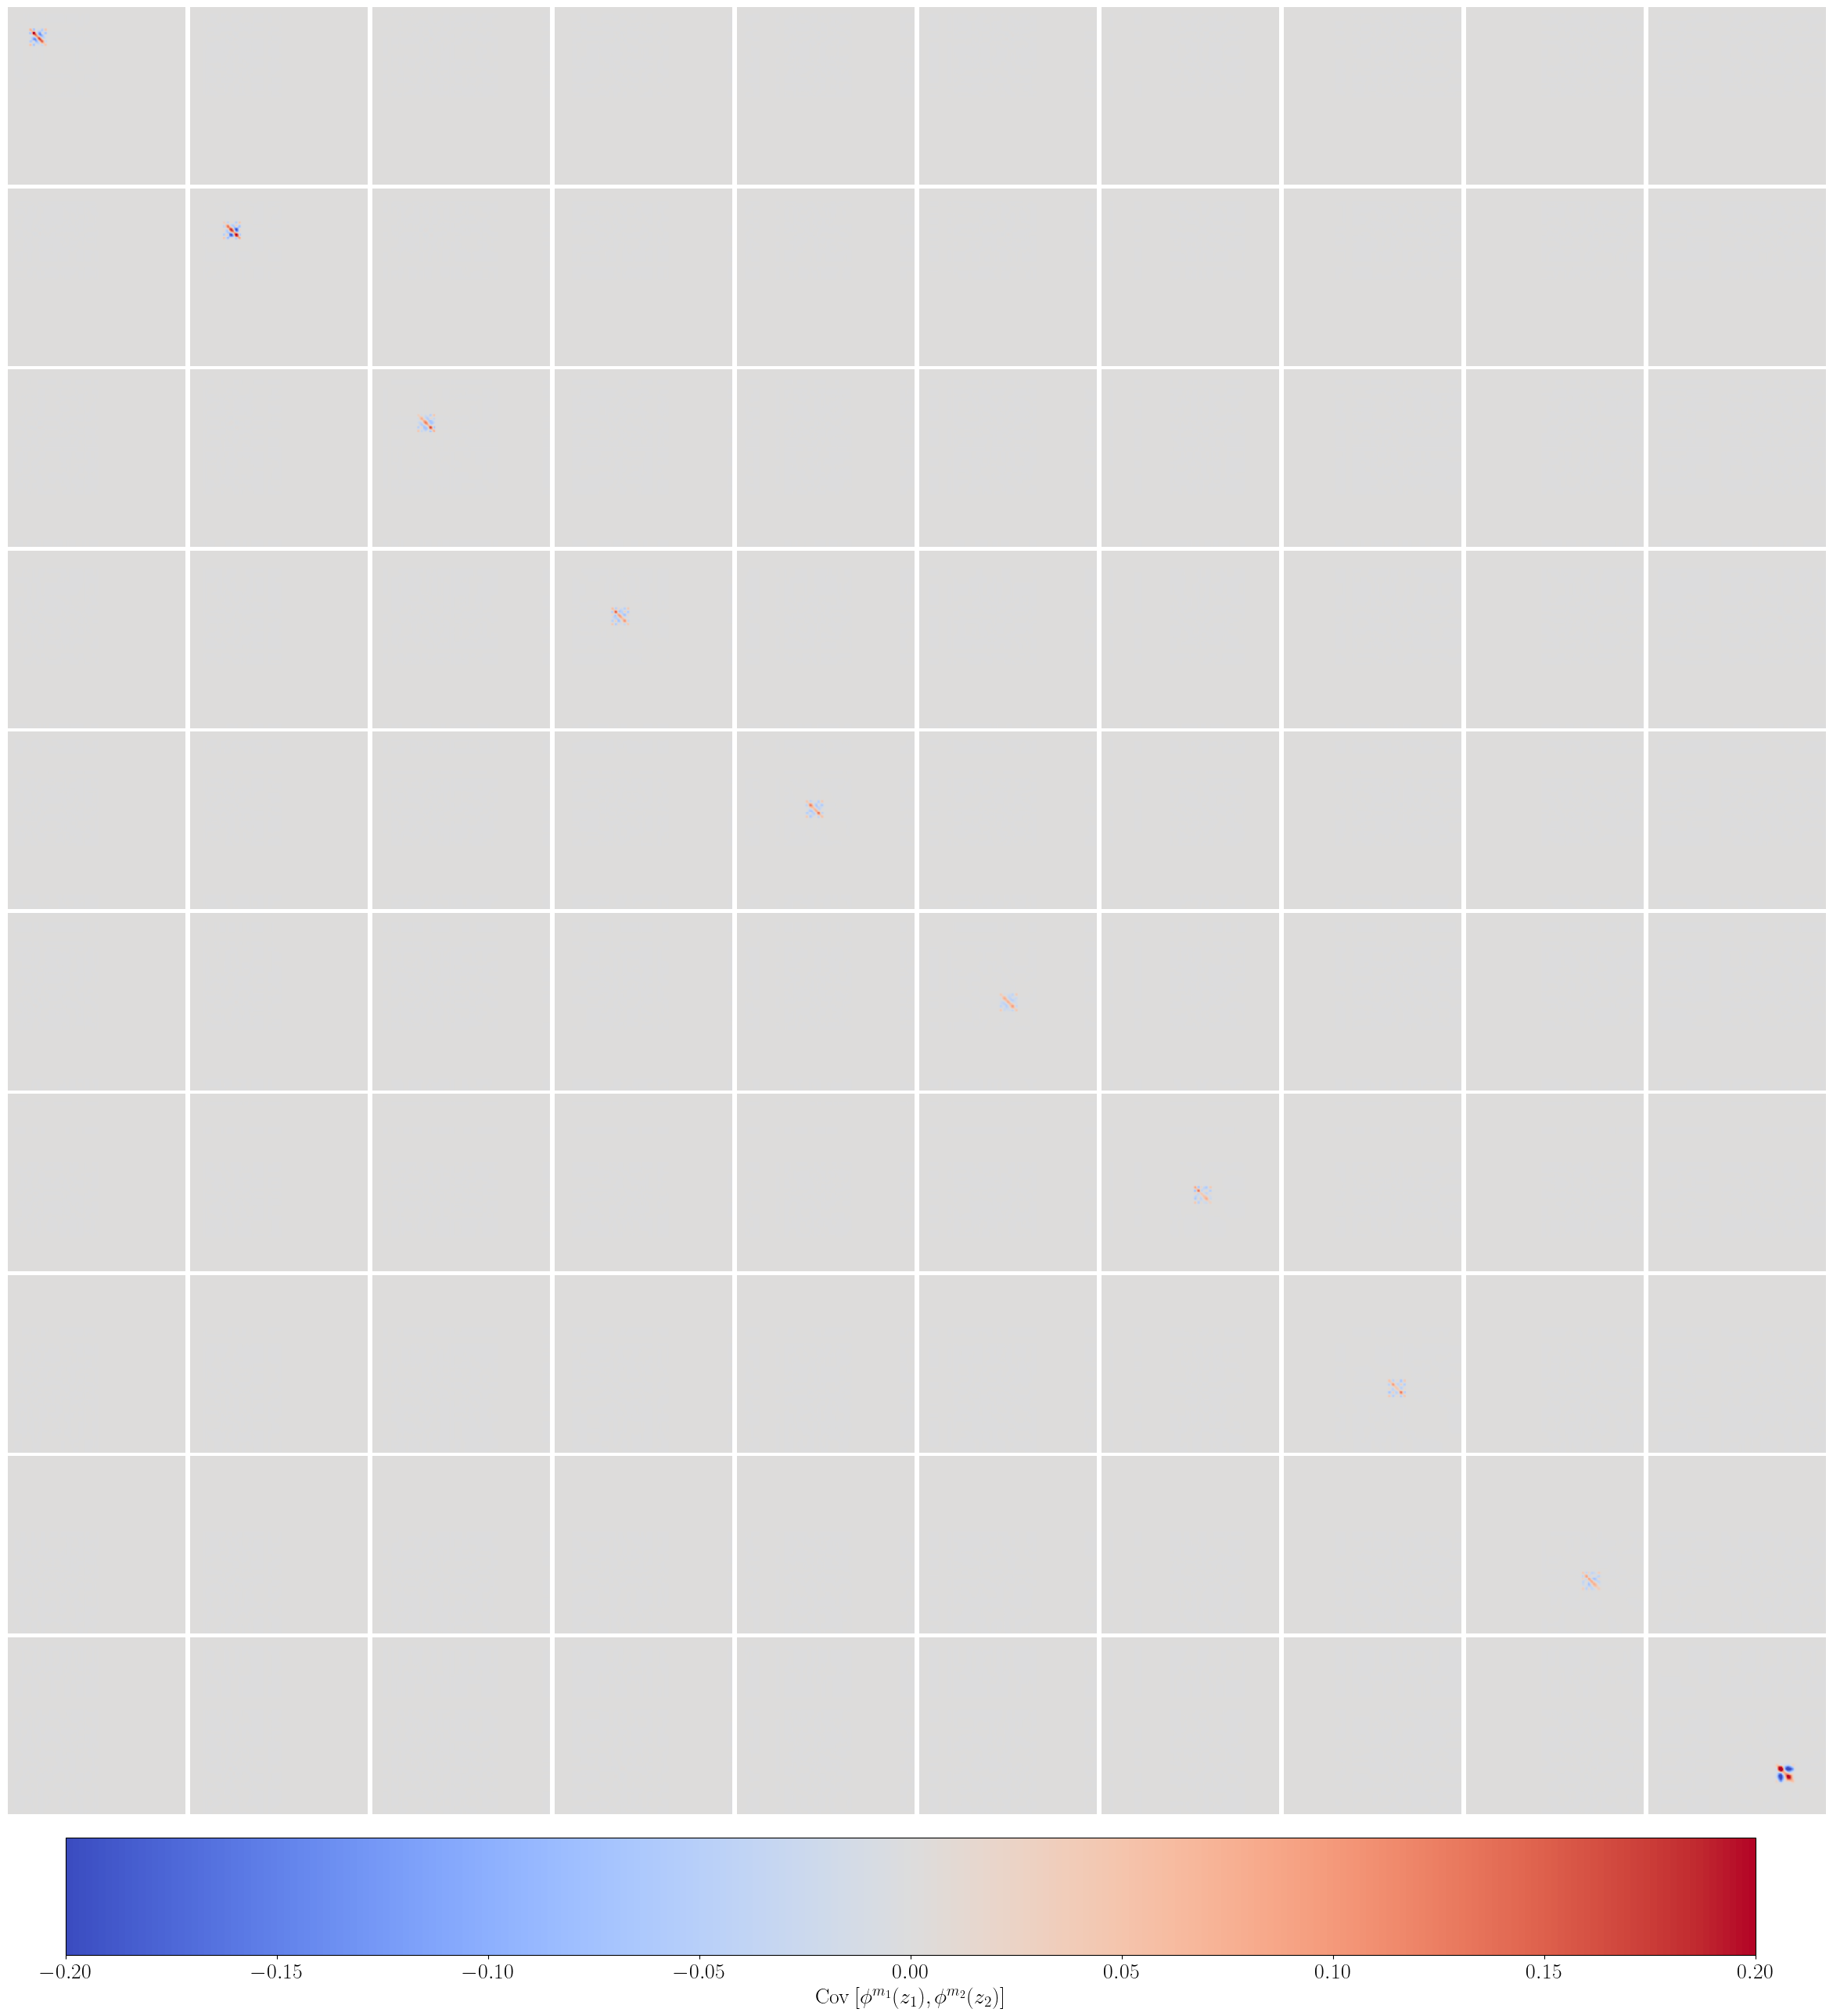

In [7]:
# Model Lens
norm = colors.Normalize(vmin = -0.1, vmax = +0.1)
figure, plot = pyplot.subplots(nrows = bin_lens_size, ncols = bin_lens_size, figsize = (3 * bin_lens_size, 3 * bin_lens_size))

for m in range(bin_lens_size):
    for n in range(bin_lens_size):
        
        model_map = model_matrix_lens[n * data_size: n * data_size + data_size // 2, m * data_size: m * data_size + data_size // 2]
        image = plot[n, m].imshow(model_map, norm = norm, cmap = 'coolwarm', origin = 'upper')
        plot[n, m].axis('off')

cax = figure.add_axes([0.15, 0.05, 0.72, 0.05])
figure.subplots_adjust(wspace = 0.02, hspace = 0.02)

os.makedirs(plot_folder, exist_ok=True)
os.makedirs(os.path.join(plot_folder, '{}/COVARIANCE/'.format(tag)), exist_ok=True)

figure.colorbar(cax = cax, mappable = image, orientation = 'horizontal', label = r'$\mathrm{Cov} \: [\phi^{m_1} (z_1), \phi^{m_2} (z_2)]$')
figure.savefig(os.path.join(plot_folder, '{}/COVARIANCE/FIGURE_MODEL_LENS.png'.format(tag)), bbox_inches='tight', format='png', dpi=512)

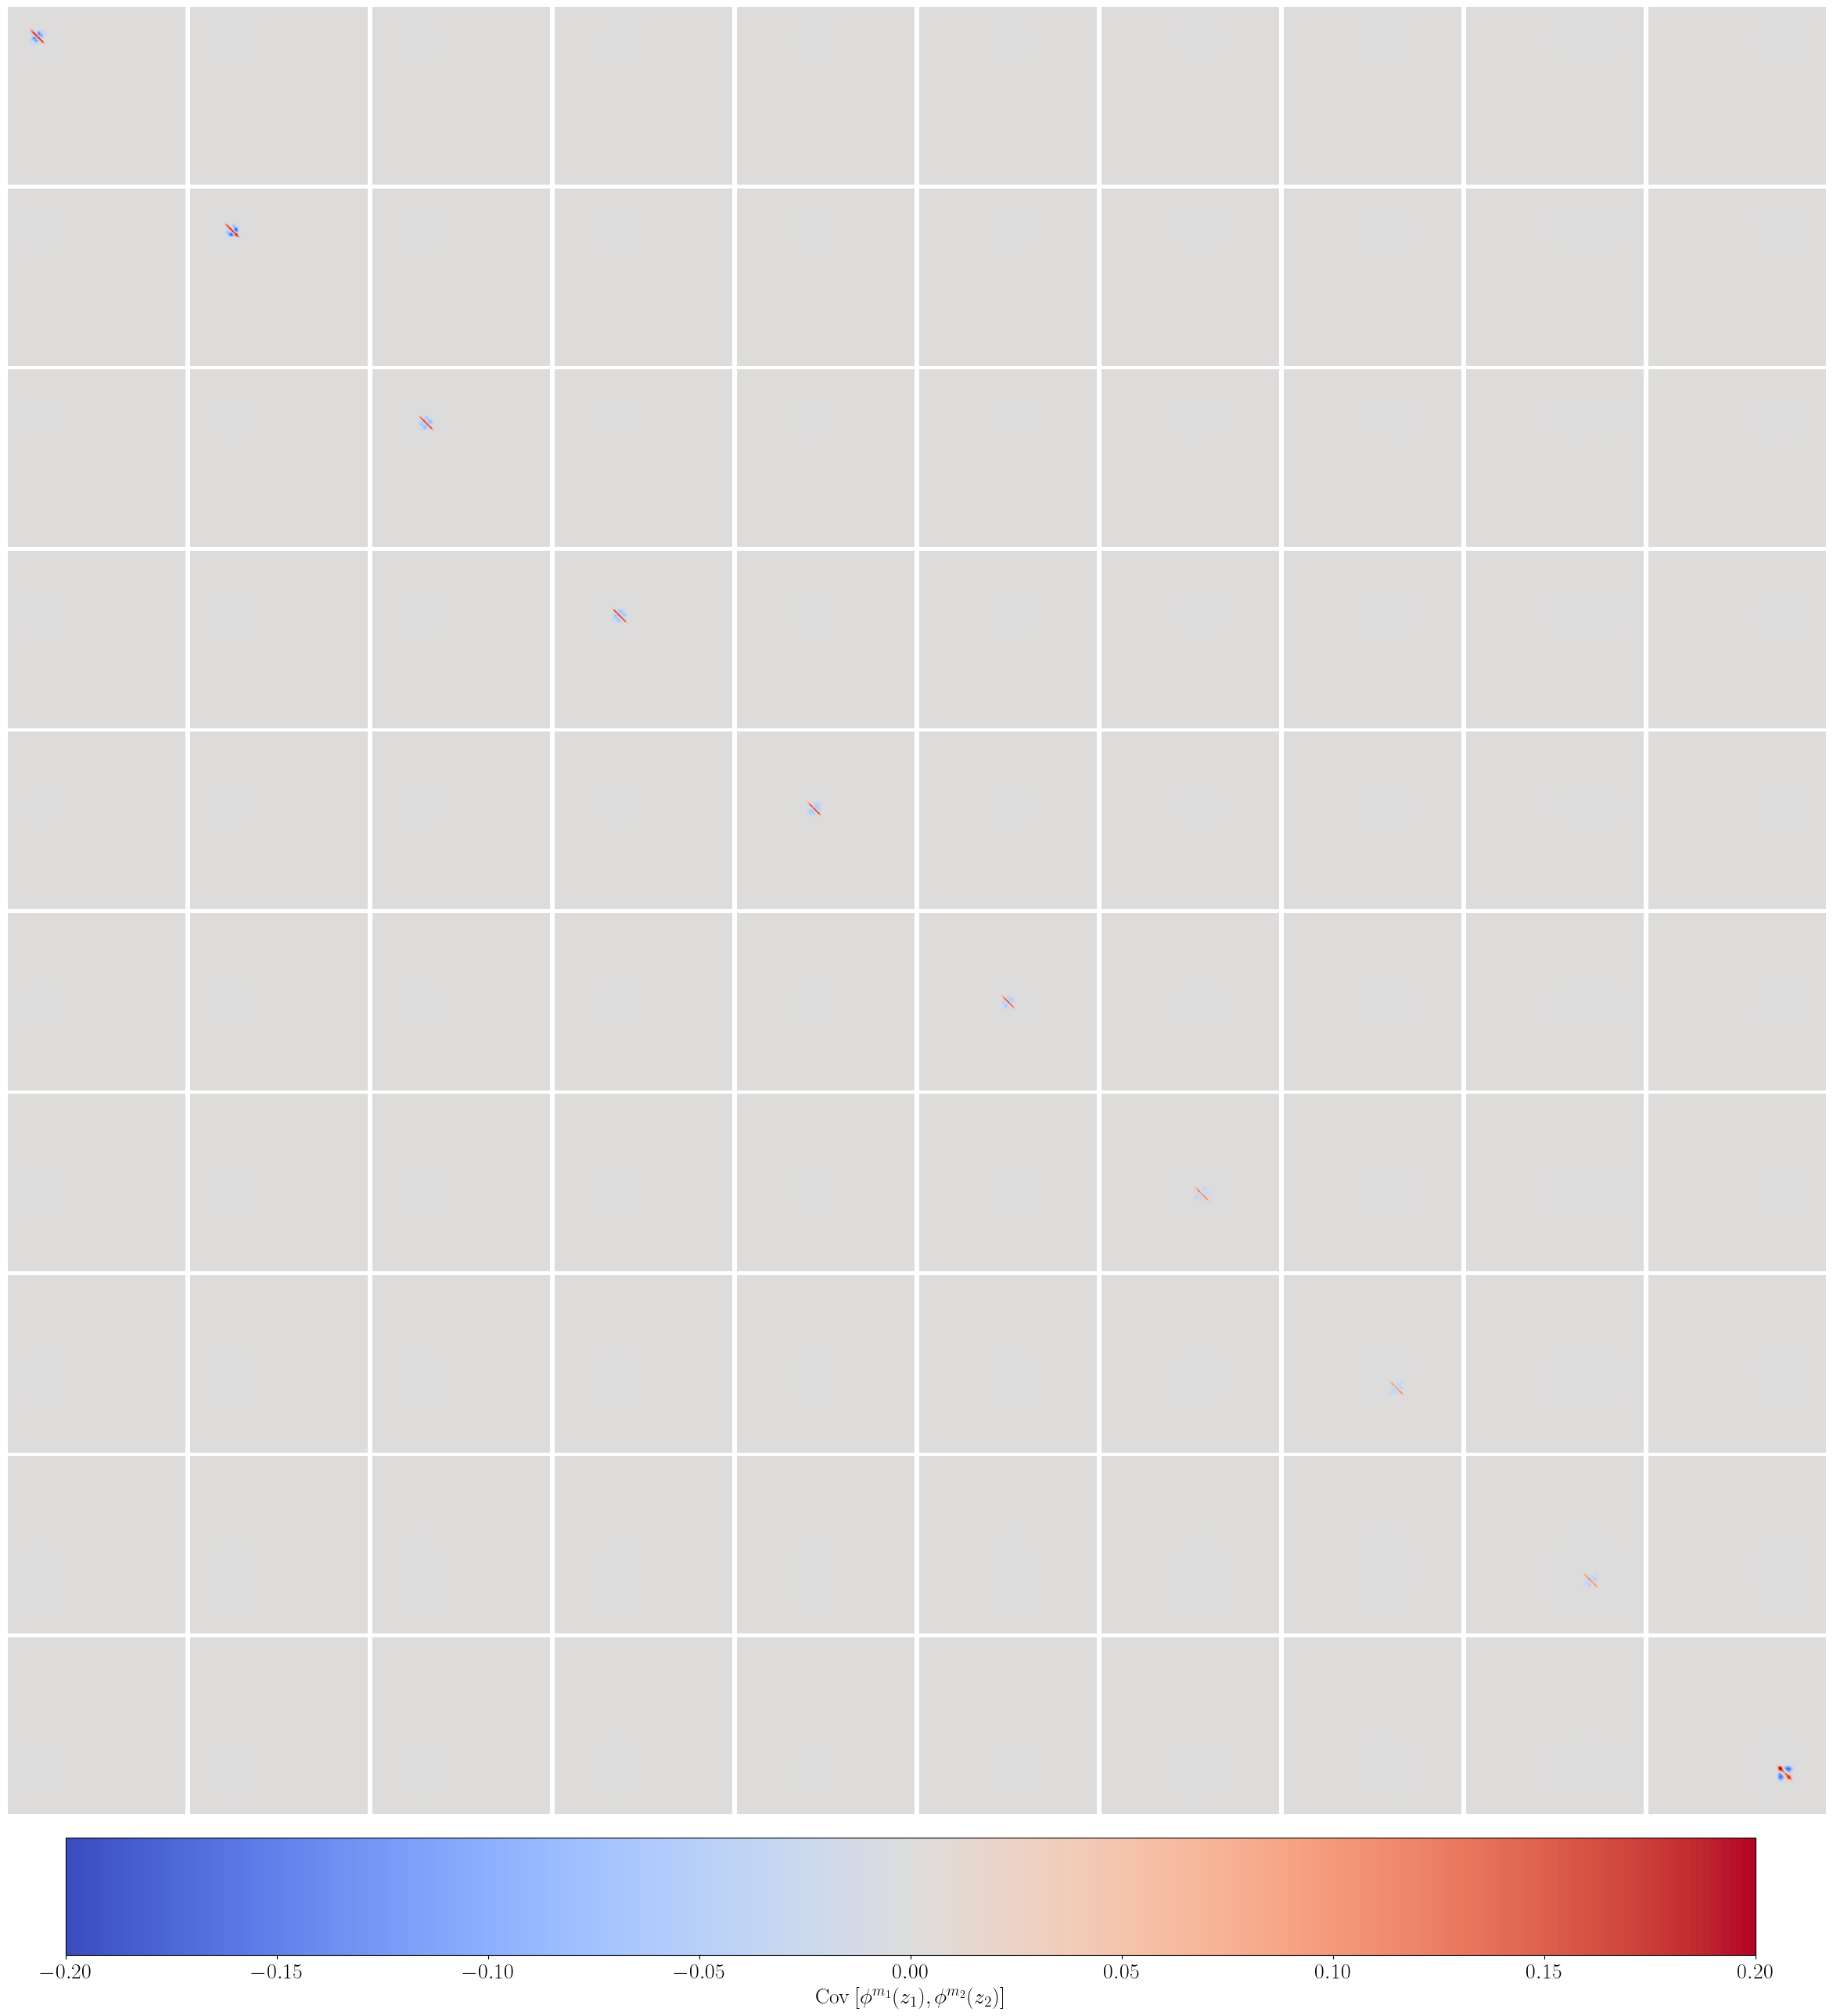

In [8]:
# Product Lens
norm = colors.Normalize(vmin = -0.1, vmax = +0.1)
figure, plot = pyplot.subplots(nrows = bin_lens_size, ncols = bin_lens_size, figsize = (3 * bin_lens_size, 3 * bin_lens_size))

for m in range(bin_lens_size):
    for n in range(bin_lens_size):
        
        product_map = product_matrix_lens[n * data_size: n * data_size + data_size // 2, m * data_size: m * data_size + data_size // 2]
        image = plot[n, m].imshow(product_map, norm = norm, cmap = 'coolwarm', origin = 'upper')
        plot[n, m].axis('off')

cax = figure.add_axes([0.15, 0.05, 0.72, 0.05])
figure.subplots_adjust(wspace = 0.02, hspace = 0.02)

os.makedirs(plot_folder, exist_ok=True)
os.makedirs(os.path.join(plot_folder, '{}/COVARIANCE/'.format(tag)), exist_ok=True)

figure.colorbar(cax = cax, mappable = image, orientation = 'horizontal', label = r'$\mathrm{Cov} \: [\phi^{m_1} (z_1), \phi^{m_2} (z_2)]$')
figure.savefig(os.path.join(plot_folder, '{}/COVARIANCE/FIGURE_PRODUCT_LENS.png'.format(tag)), bbox_inches='tight', format='png', dpi=512)

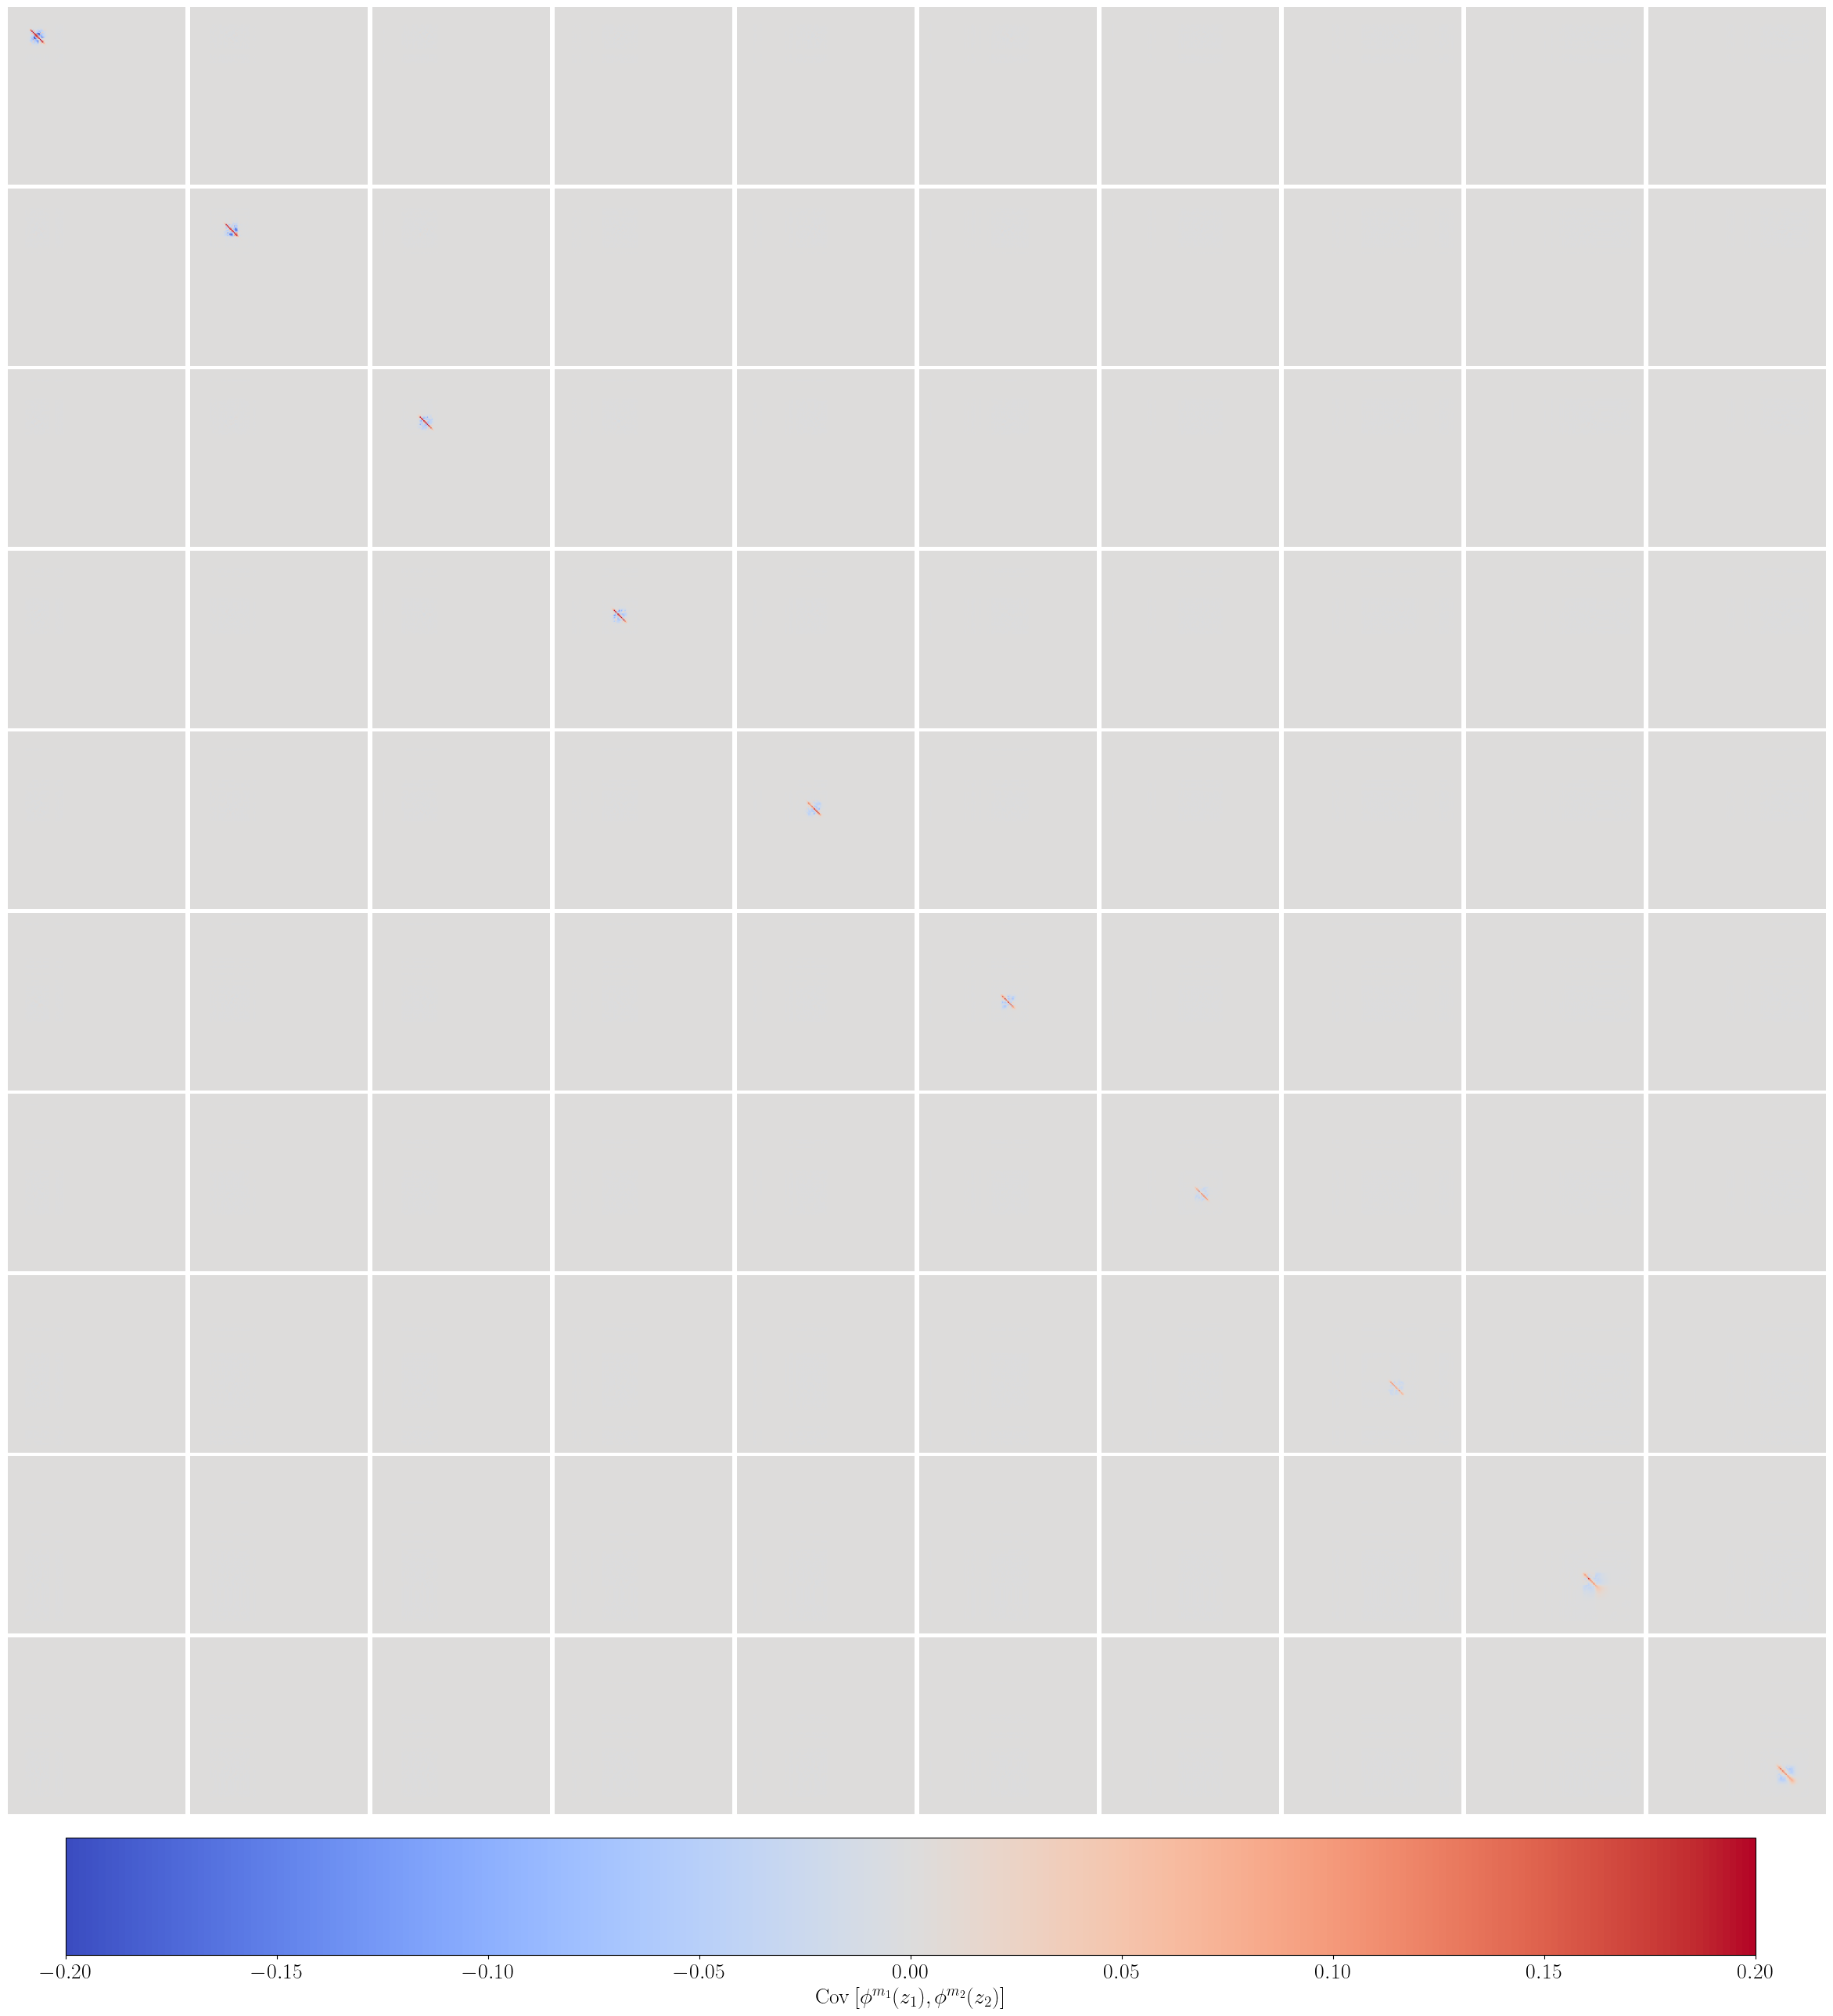

In [9]:
# Histogram Lens
norm = colors.Normalize(vmin = -0.1, vmax = +0.1)
figure, plot = pyplot.subplots(nrows = bin_lens_size, ncols = bin_lens_size, figsize = (3 * bin_lens_size, 3 * bin_lens_size))

for m in range(bin_lens_size):
    for n in range(bin_lens_size):
        
        histogram_map = histogram_matrix_lens[n * data_size: n * data_size + data_size // 2, m * data_size: m * data_size + data_size // 2]
        image = plot[n, m].imshow(histogram_map, norm = norm, cmap = 'coolwarm', origin = 'upper')
        plot[n, m].axis('off')

cax = figure.add_axes([0.15, 0.05, 0.72, 0.05])
figure.subplots_adjust(wspace = 0.02, hspace = 0.02)

os.makedirs(plot_folder, exist_ok=True)
os.makedirs(os.path.join(plot_folder, '{}/COVARIANCE/'.format(tag)), exist_ok=True)

figure.colorbar(cax = cax, mappable = image, orientation = 'horizontal', label = r'$\mathrm{Cov} \: [\phi^{m_1} (z_1), \phi^{m_2} (z_2)]$')
figure.savefig(os.path.join(plot_folder, '{}/COVARIANCE/FIGURE_MODEL_LENS.png'.format(tag)), bbox_inches='tight', format='png', dpi=512)

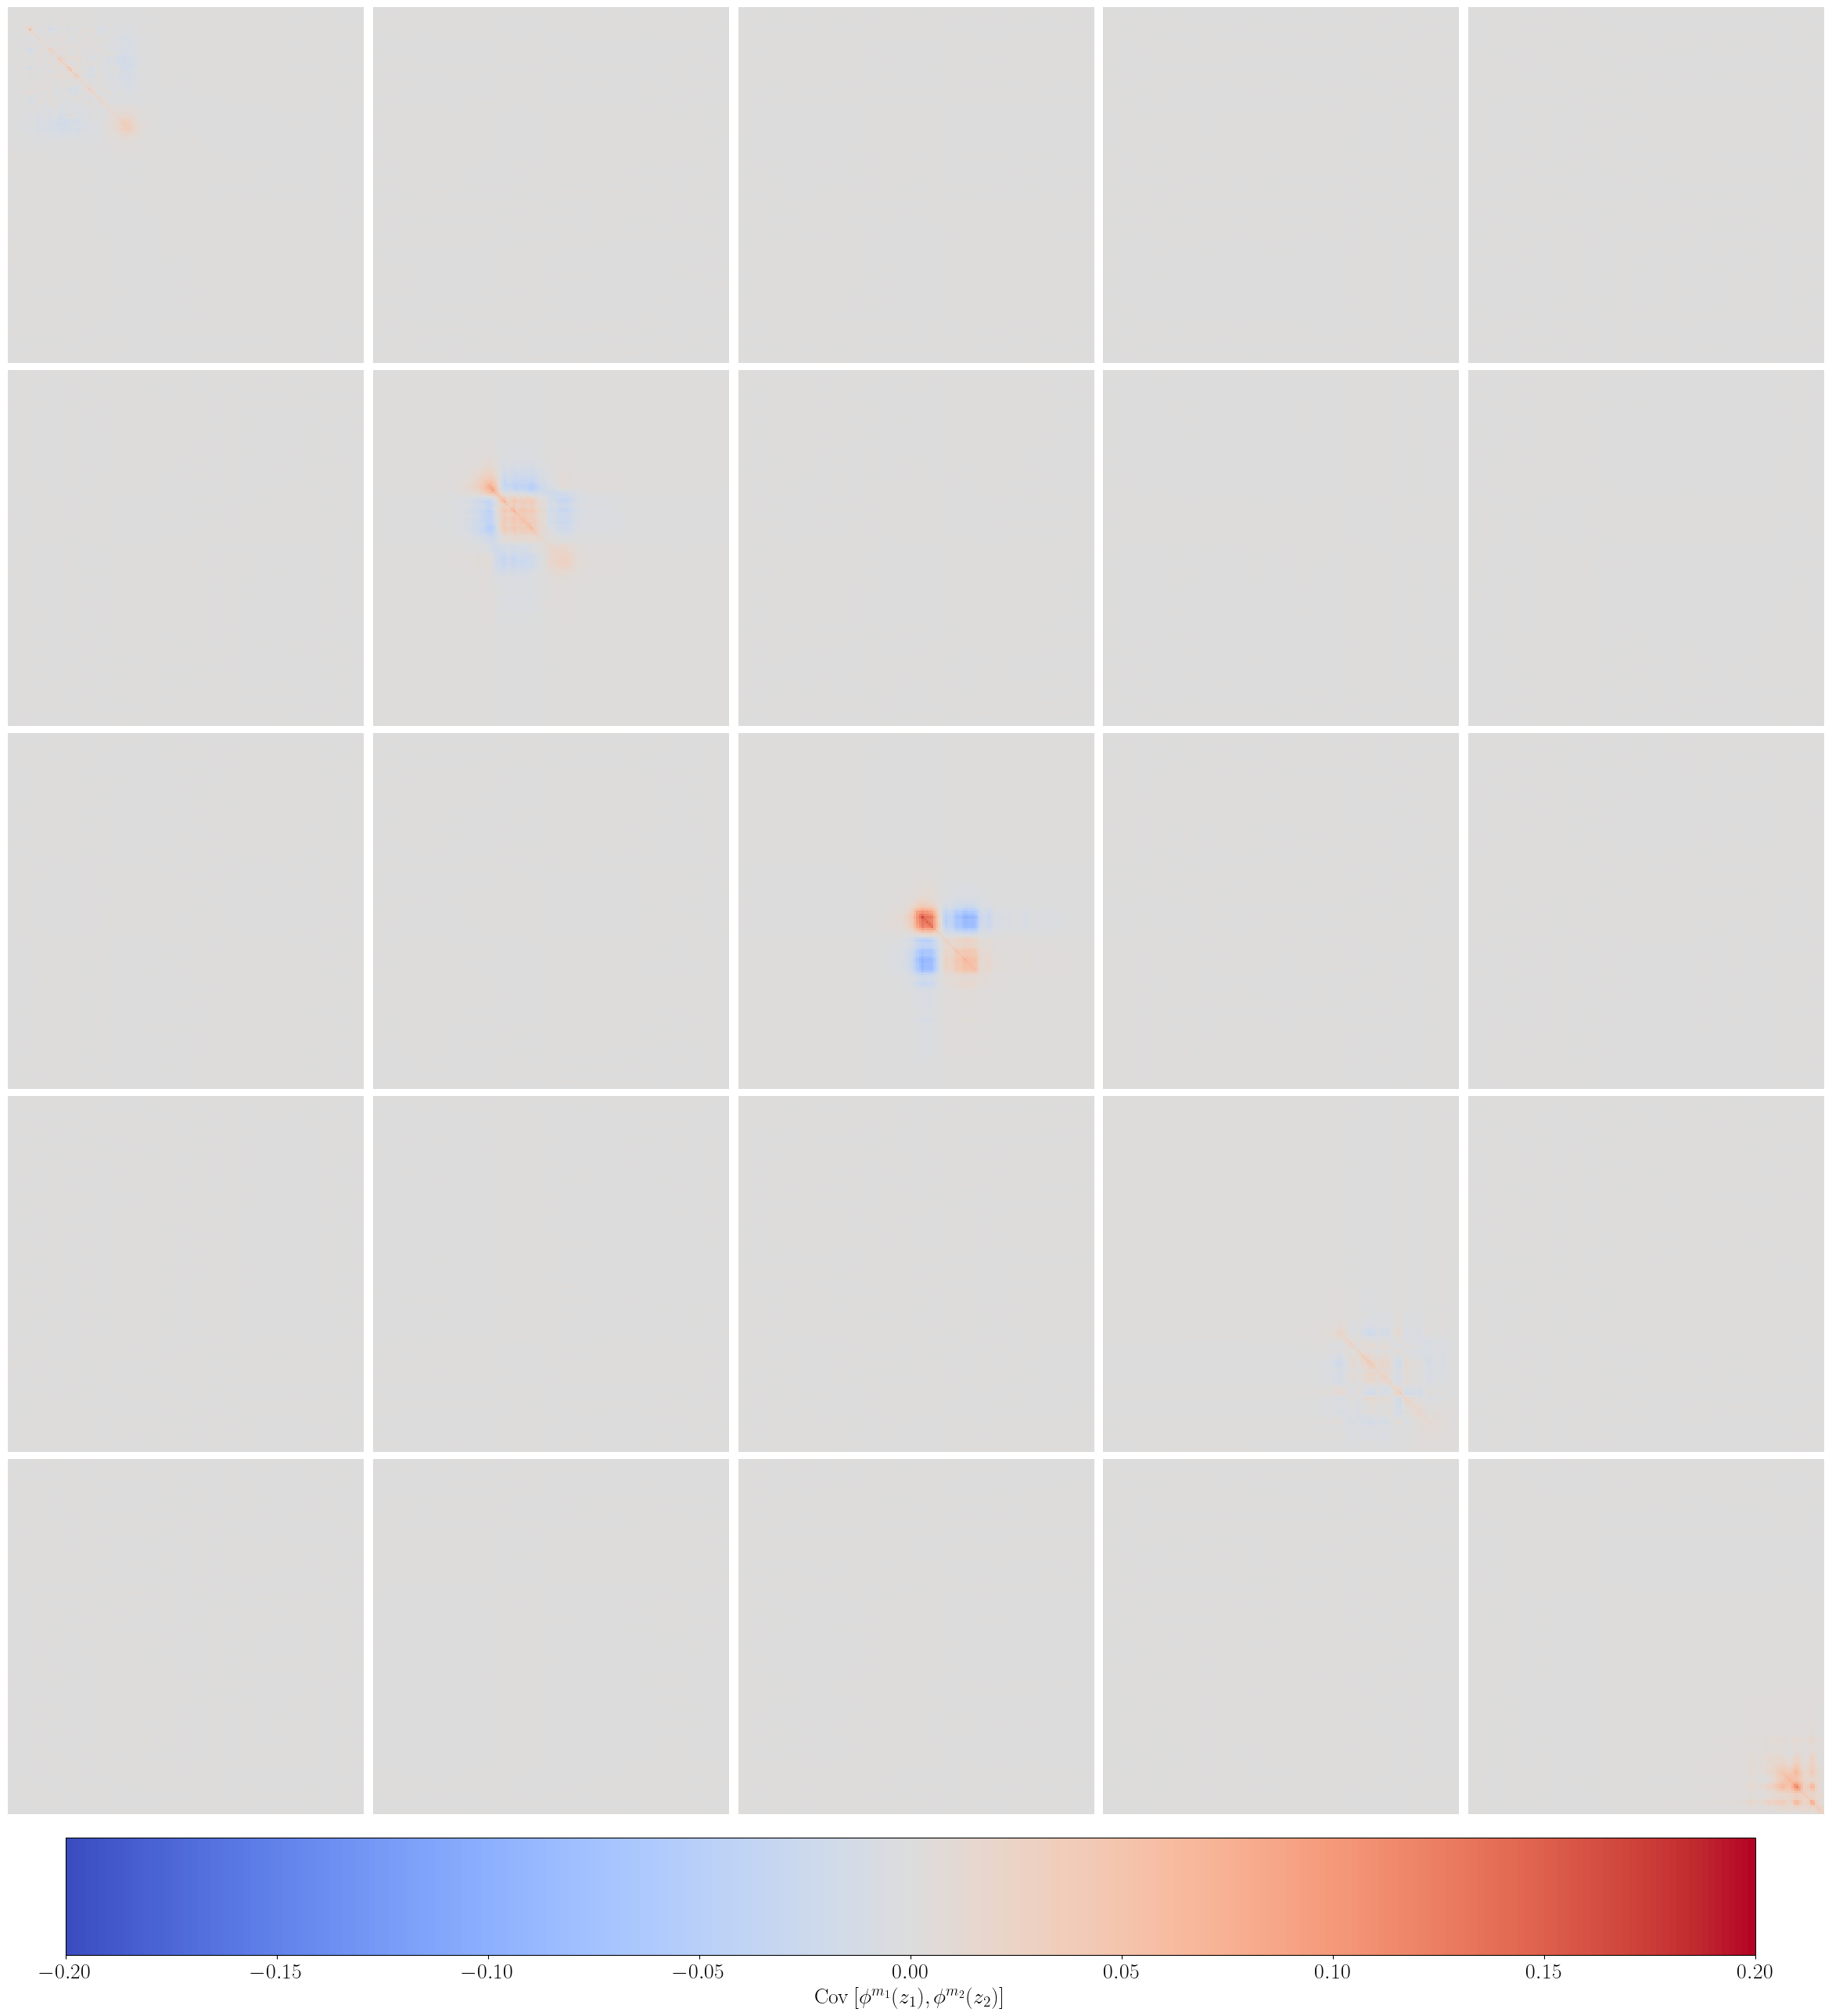

In [14]:
# SOM Source
norm = colors.Normalize(vmin = -0.2, vmax = +0.2)
figure, plot = pyplot.subplots(nrows = bin_source_size, ncols = bin_source_size, figsize = (3 * bin_lens_size, 3 * bin_lens_size))

for m in range(bin_source_size):
    for n in range(bin_source_size):
        
        som_map = som_matrix_source[n * data_size: n * data_size + data_size // 2, m * data_size: m * data_size + data_size // 2]
        image = plot[n, m].imshow(som_map, norm = norm, cmap = 'coolwarm', origin = 'upper')
        plot[n, m].axis('off')

cax = figure.add_axes([0.15, 0.05, 0.72, 0.05])
figure.subplots_adjust(wspace = 0.02, hspace = 0.02)

os.makedirs(plot_folder, exist_ok=True)
os.makedirs(os.path.join(plot_folder, '{}/COVARIANCE/'.format(tag)), exist_ok=True)

figure.colorbar(cax = cax, mappable = image, orientation = 'horizontal', label = r'$\mathrm{Cov} \: [\phi^{m_1} (z_1), \phi^{m_2} (z_2)]$')
figure.savefig(os.path.join(plot_folder, '{}/COVARIANCE/FIGURE_SOM_SOURCE.png'.format(tag)), bbox_inches='tight', format='png', dpi=512)

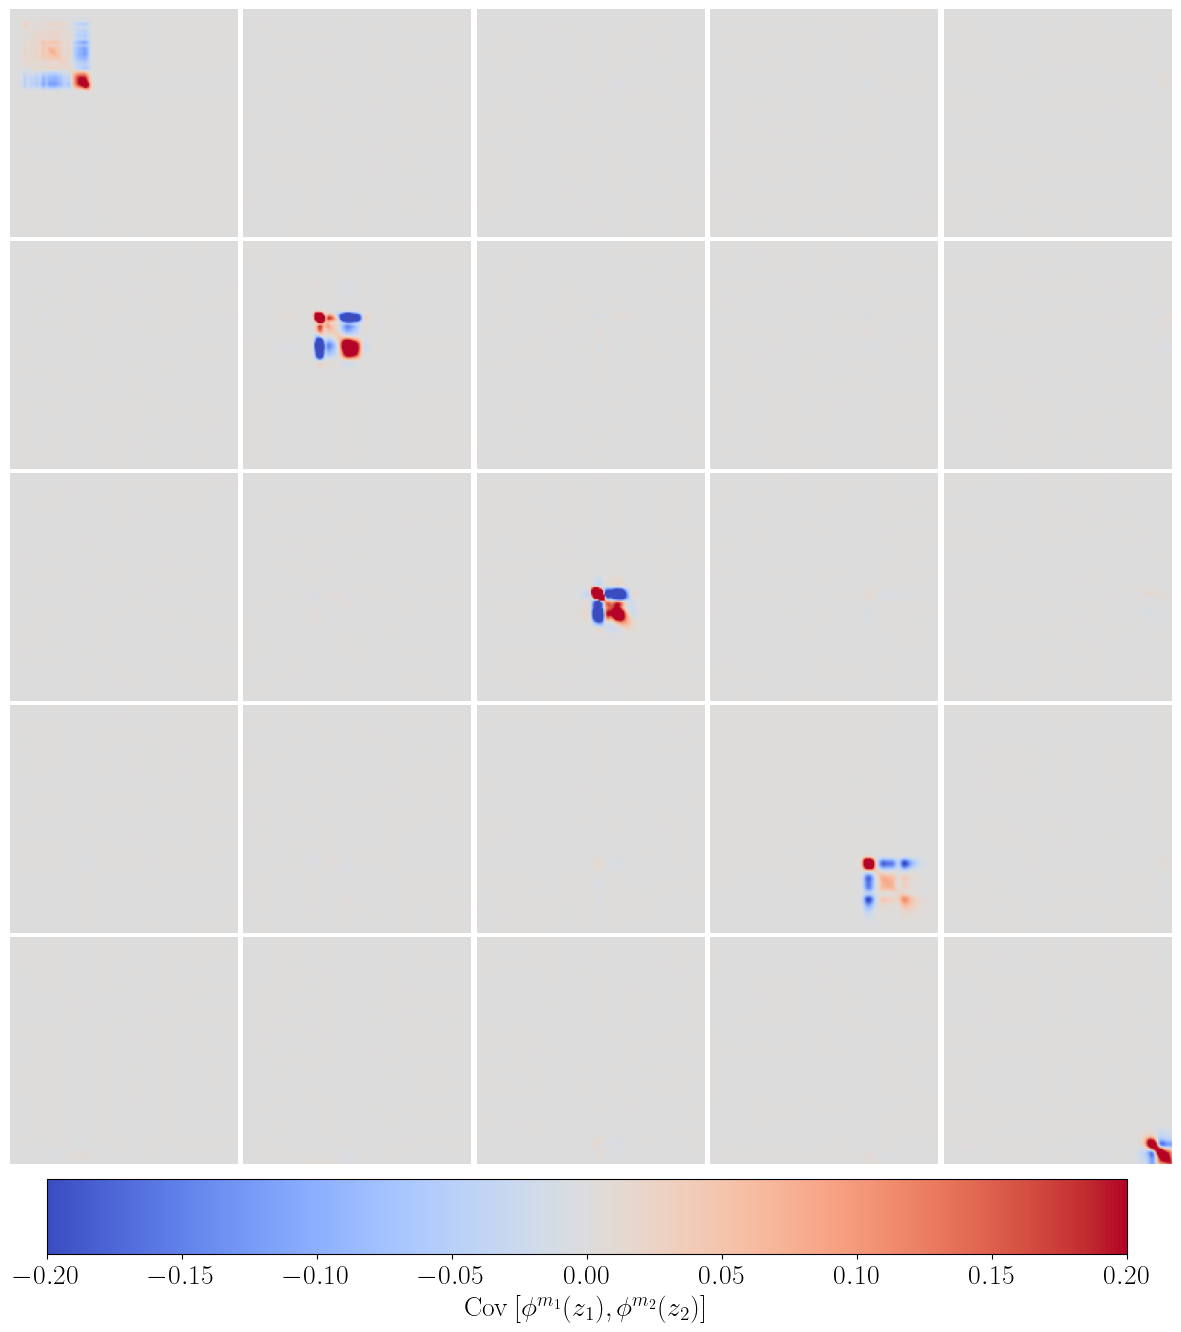

In [11]:
# Model Source
norm = colors.Normalize(vmin = -0.2, vmax = +0.2)
figure, plot = pyplot.subplots(nrows = bin_source_size, ncols = bin_source_size, figsize = (3 * bin_source_size, 3 * bin_source_size))

for m in range(bin_source_size):
    for n in range(bin_source_size):
        
        model_map = model_matrix_source[n * data_size: n * data_size + data_size // 2, m * data_size: m * data_size + data_size // 2]
        image = plot[n, m].imshow(model_map, norm = norm, cmap = 'coolwarm', origin = 'upper')
        plot[n, m].axis('off')

cax = figure.add_axes([0.15, 0.05, 0.72, 0.05])
figure.subplots_adjust(wspace = 0.02, hspace = 0.02)

os.makedirs(plot_folder, exist_ok=True)
os.makedirs(os.path.join(plot_folder, '{}/COVARIANCE/'.format(tag)), exist_ok=True)

figure.colorbar(cax = cax, mappable = image, orientation = 'horizontal', label = r'$\mathrm{Cov} \: [\phi^{m_1} (z_1), \phi^{m_2} (z_2)]$')
figure.savefig(os.path.join(plot_folder, '{}/COVARIANCE/FIGURE_MODEL_SOURCE.png'.format(tag)), bbox_inches='tight', format='png', dpi=512)

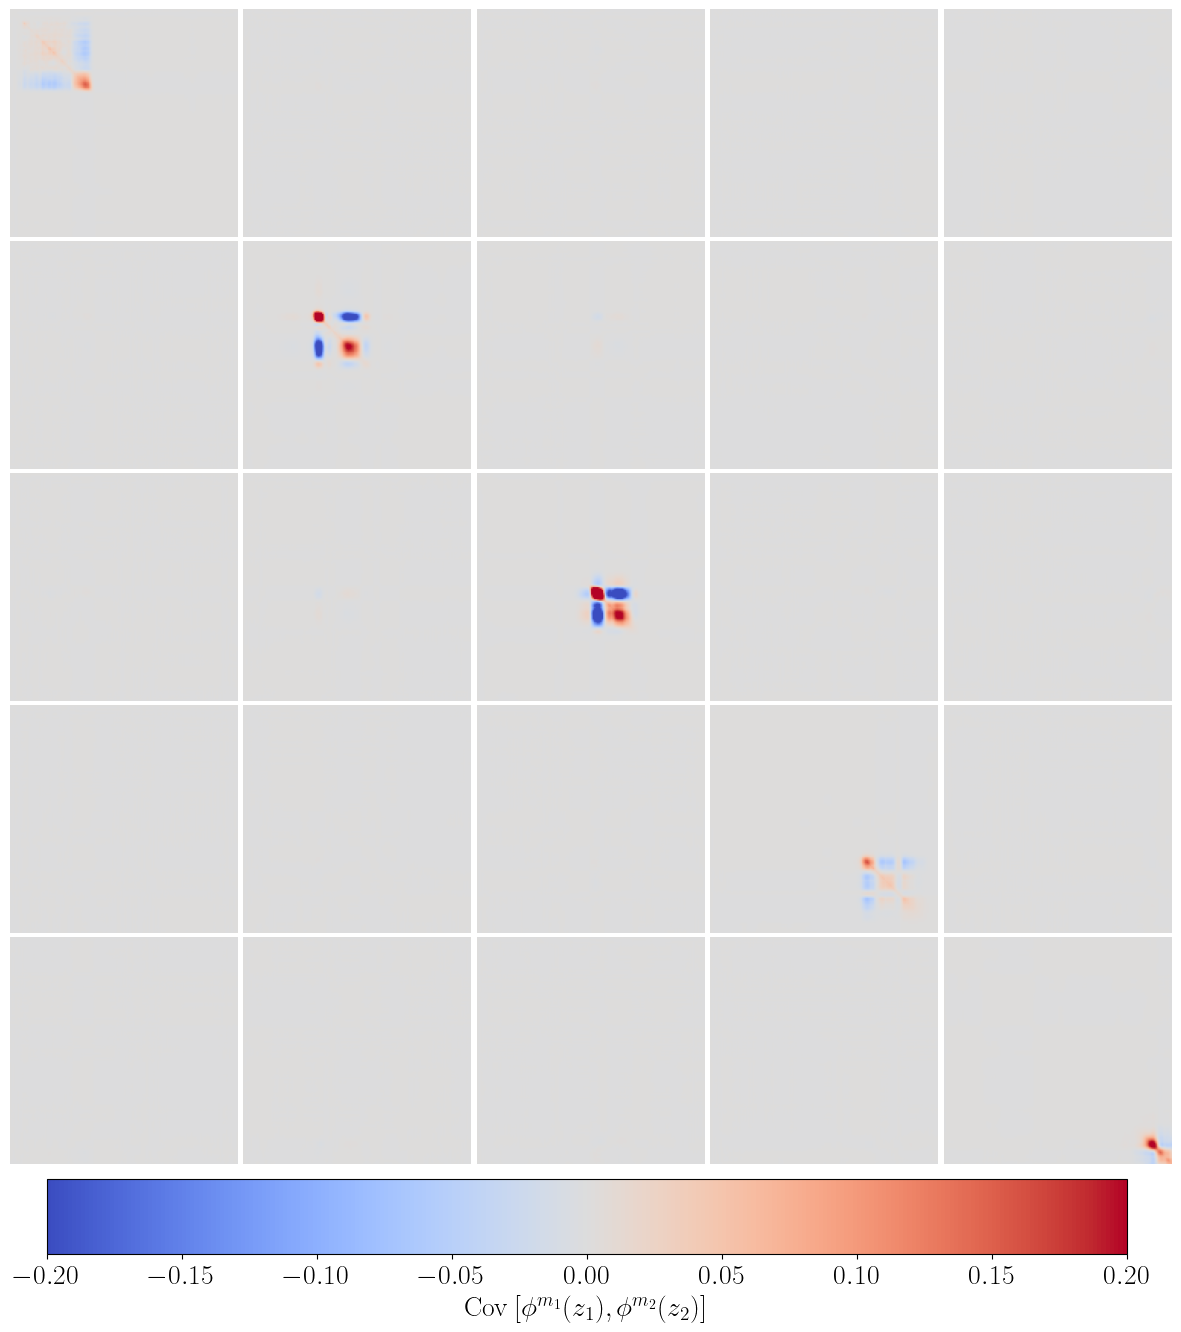

In [12]:
# Product Source
norm = colors.Normalize(vmin = -0.2, vmax = +0.2)
figure, plot = pyplot.subplots(nrows = bin_source_size, ncols = bin_source_size, figsize = (3 * bin_source_size, 3 * bin_source_size))

for m in range(bin_source_size):
    for n in range(bin_source_size):
        
        model_map = product_matrix_source[n * data_size: n * data_size + data_size // 2, m * data_size: m * data_size + data_size // 2]
        image = plot[n, m].imshow(model_map, norm = norm, cmap = 'coolwarm', origin = 'upper')
        plot[n, m].axis('off')

cax = figure.add_axes([0.15, 0.05, 0.72, 0.05])
figure.subplots_adjust(wspace = 0.02, hspace = 0.02)

os.makedirs(plot_folder, exist_ok=True)
os.makedirs(os.path.join(plot_folder, '{}/COVARIANCE/'.format(tag)), exist_ok=True)

figure.colorbar(cax = cax, mappable = image, orientation = 'horizontal', label = r'$\mathrm{Cov} \: [\phi^{m_1} (z_1), \phi^{m_2} (z_2)]$')
figure.savefig(os.path.join(plot_folder, '{}/COVARIANCE/FIGURE_PRODUCT_SOURCE.png'.format(tag)), bbox_inches='tight', format='png', dpi=512)

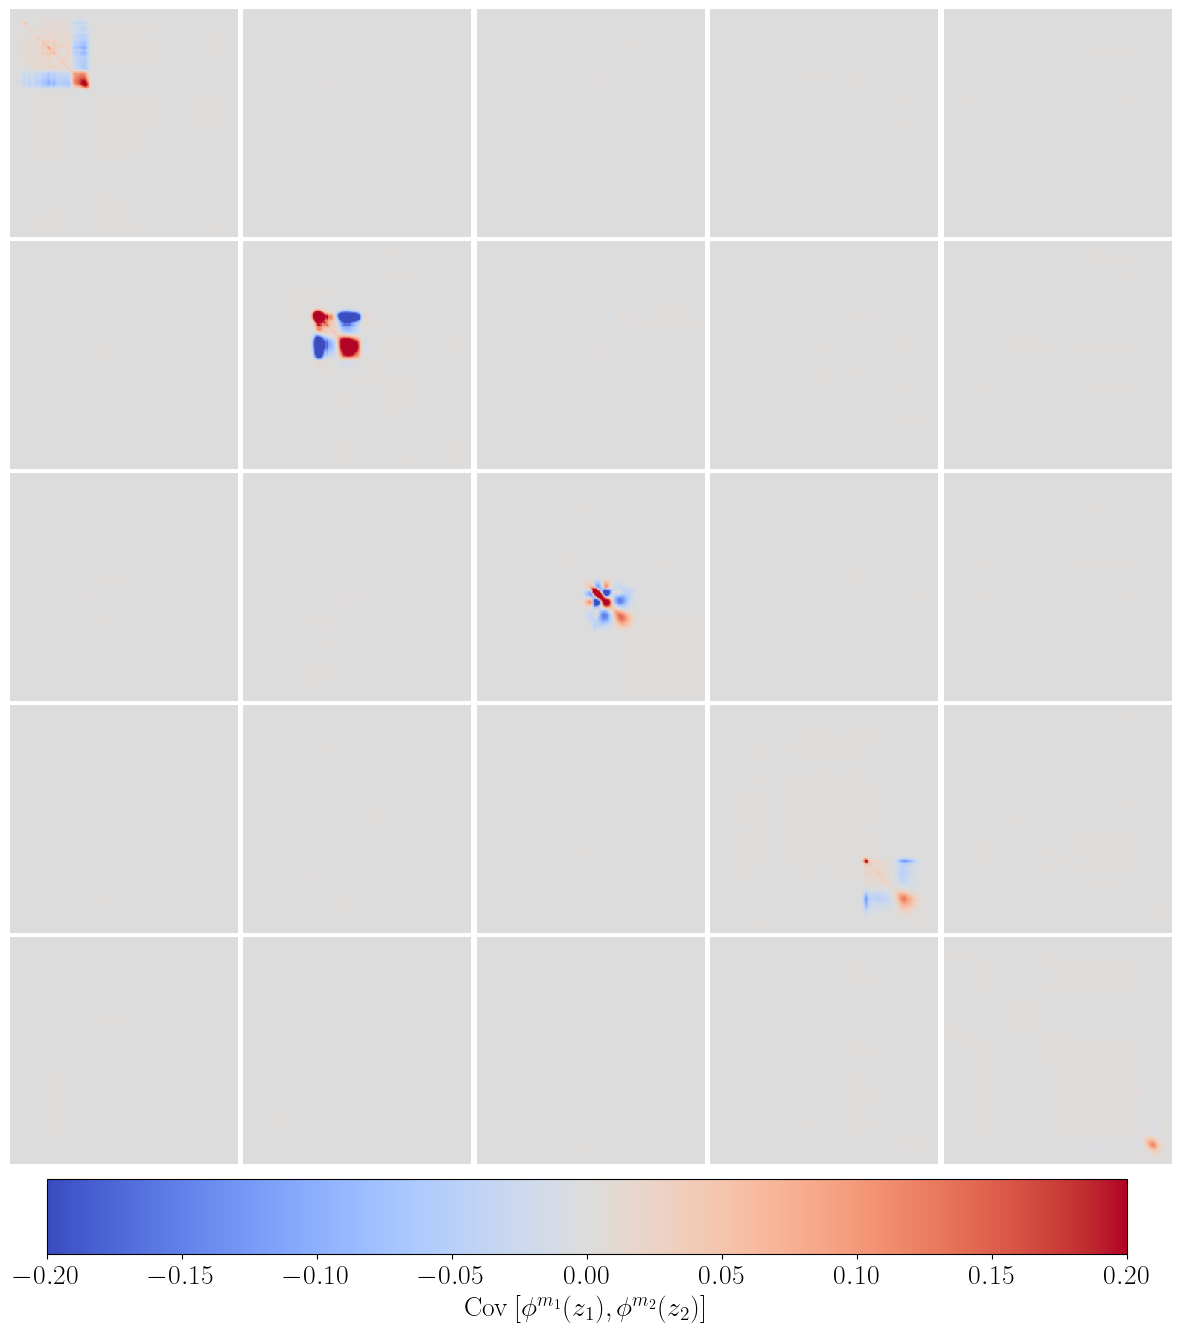

In [13]:
# Histogram Source
norm = colors.Normalize(vmin = -0.2, vmax = +0.2)
figure, plot = pyplot.subplots(nrows = bin_source_size, ncols = bin_source_size, figsize = (3 * bin_source_size, 3 * bin_source_size))

for m in range(bin_source_size):
    for n in range(bin_source_size):
        
        model_map = histogram_matrix_source[n * data_size: n * data_size + data_size // 2, m * data_size: m * data_size + data_size // 2]
        image = plot[n, m].imshow(model_map, norm = norm, cmap = 'coolwarm', origin = 'upper')
        plot[n, m].axis('off')

cax = figure.add_axes([0.15, 0.05, 0.72, 0.05])
figure.subplots_adjust(wspace = 0.02, hspace = 0.02)

os.makedirs(plot_folder, exist_ok=True)
os.makedirs(os.path.join(plot_folder, '{}/COVARIANCE/'.format(tag)), exist_ok=True)

figure.colorbar(cax = cax, mappable = image, orientation = 'horizontal', label = r'$\mathrm{Cov} \: [\phi^{m_1} (z_1), \phi^{m_2} (z_2)]$')
figure.savefig(os.path.join(plot_folder, '{}/COVARIANCE/FIGURE_HISTOGRAM_SOURCE.png'.format(tag)), bbox_inches='tight', format='png', dpi=512)